### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

## Data Preprocessing

1. Loading NASA CMAPSS Dataset

In [2]:
data = pd.read_csv("NASA_CMAPSS_Train_All.csv")

data.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset,engine_id
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,FD001_1


2. Dataset Dimensions

In [3]:
data.shape

(160359, 28)

3. Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 28 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   unit_number   160359 non-null  int64  
 1   time_cycles   160359 non-null  int64  
 2   op_setting_1  160359 non-null  float64
 3   op_setting_2  160359 non-null  float64
 4   op_setting_3  160359 non-null  float64
 5   sensor_1      160359 non-null  float64
 6   sensor_2      160359 non-null  float64
 7   sensor_3      160359 non-null  float64
 8   sensor_4      160359 non-null  float64
 9   sensor_5      160359 non-null  float64
 10  sensor_6      160359 non-null  float64
 11  sensor_7      160359 non-null  float64
 12  sensor_8      160359 non-null  float64
 13  sensor_9      160359 non-null  float64
 14  sensor_10     160359 non-null  float64
 15  sensor_11     160359 non-null  float64
 16  sensor_12     160359 non-null  float64
 17  sensor_13     160359 non-null  float64
 18  sens

4. Statistical Description

In [5]:
data.describe()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,...,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000,160359.000000
mean,105.553758,123.331338,17.211973,0.410004,95.724344,485.840890,597.361022,1467.035653,1260.956434,9.894999,...,338.789821,2349.645243,8088.950972,9.054747,0.025185,360.698801,2273.754039,98.389146,25.942709,15.565700
std,72.867325,83.538146,16.527988,0.367938,12.359044,30.420388,42.478516,118.175261,136.300073,4.265554,...,164.193480,111.167242,80.623257,0.751581,0.004997,31.021430,142.513114,4.656270,11.691422,7.015067
min,1.000000,1.000000,-0.008700,-0.000600,60.000000,445.000000,535.480000,1242.670000,1023.770000,3.910000,...,128.310000,2027.570000,7845.780000,8.156300,0.020000,302.000000,1915.000000,84.930000,10.160000,6.010500
25%,44.000000,57.000000,0.001300,0.000200,100.000000,449.440000,549.960000,1357.360000,1126.830000,5.480000,...,164.790000,2387.970000,8070.530000,8.439250,0.020000,332.000000,2212.000000,100.000000,14.330000,8.601300
50%,89.000000,114.000000,19.998100,0.620000,100.000000,489.050000,605.930000,1492.810000,1271.740000,9.350000,...,321.690000,2388.070000,8118.590000,9.030100,0.030000,367.000000,2319.000000,100.000000,24.920000,14.953500
75%,164.000000,173.000000,35.001500,0.840000,100.000000,518.670000,642.340000,1586.590000,1402.200000,14.620000,...,521.340000,2388.160000,8139.410000,9.344200,0.030000,392.000000,2388.000000,100.000000,38.820000,23.294600
max,260.000000,543.000000,42.008000,0.842000,100.000000,518.670000,645.110000,1616.910000,1441.490000,14.620000,...,537.490000,2390.490000,8293.720000,11.066900,0.030000,400.000000,2388.000000,100.000000,39.890000,23.950500


5. Missing Values Analysis

In [6]:
data.isnull().sum()

unit_number     0
time_cycles     0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
dataset         0
engine_id       0
dtype: int64

6. Data columns 


In [7]:
data.columns

Index(['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2',
       'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21', 'dataset', 'engine_id'],
      dtype='object')

### Transforming NASA CMAPSS Data into a Supervised Classification Problem

1. Creating Remaining Useful Life

In [8]:
max_cycle = data.groupby("unit_number")["time_cycles"].max()

max_cycle = max_cycle.reset_index()

max_cycle.columns = ["unit_number", "max_cycle"]

data = data.merge(max_cycle, on="unit_number")

data["RUL"] = data["max_cycle"] - data["time_cycles"]

data.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset,engine_id,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,FD001,FD001_1,321,320
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,FD001,FD001_1,321,319
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,FD001,FD001_1,321,318
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,FD001,FD001_1,321,317
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,FD001,FD001_1,321,316


2. Creating Fault Classification Labels

* 0 = Healthy Engine

* 1 = Faulty Engine 

In [9]:
data["Fault"] = np.where(data["RUL"] <= 30, 1, 0)



3.  Verifying Fault Labels

In [10]:
data[["RUL", "Fault"]].head(5)

,RUL,Fault
0,320,0
1,319,0
2,318,0
3,317,0
4,316,0


In [11]:
data[data["Fault"] == 1][["RUL", "Fault"]].head(5)

,RUL,Fault
460,30,1
461,29,1
462,28,1
463,27,1
464,26,1


In [12]:
data.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset,engine_id,max_cycle,RUL,Fault
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,FD001,FD001_1,321,320,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,FD001,FD001_1,321,319,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,FD001,FD001_1,321,318,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,FD001,FD001_1,321,317,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,FD001,FD001_1,321,316,0


### Exploratory Data Analysis and Dataset Visualization

1.  Fault Class Distribution

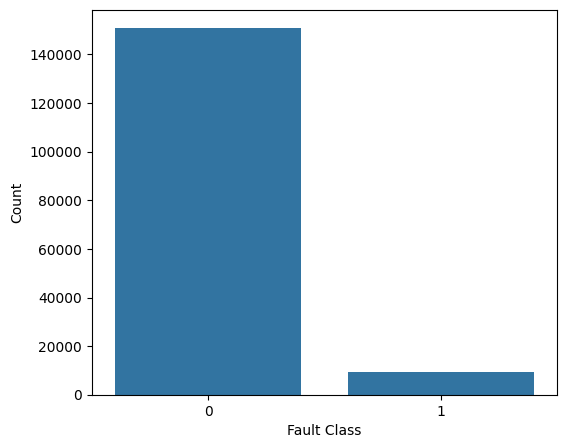

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x=data["Fault"])

plt.xlabel("Fault Class")
plt.ylabel("Count")

plt.show()

2. Remaining Useful Life Distribution

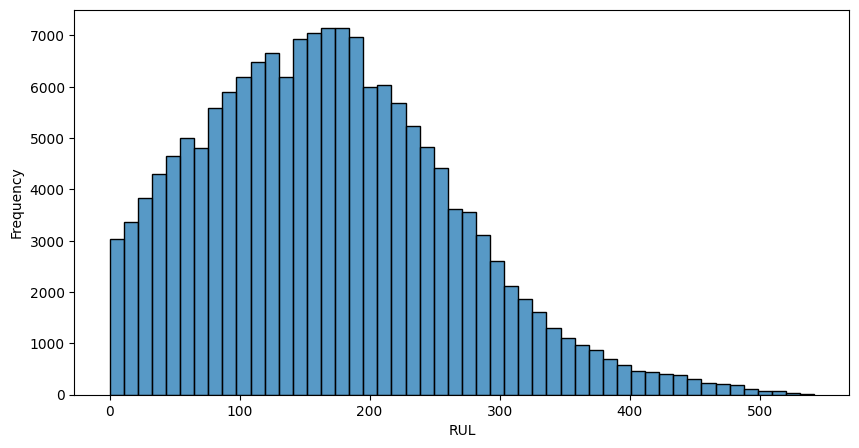

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(data["RUL"], bins=50)

plt.xlabel("RUL")
plt.ylabel("Frequency")

plt.show()

3. Correlation Between Sensors and Fault State

### Common Interpretation Rules

| Correlation \(r\) | Meaning |
|---|---|
| \(0\) | No correlation |
| \(0.0  rightarrow 0.2\) | Very weak positive |
| \(0.2  rightarrow 0.4\) | Weak positive |
| \(0.4  rightarrow 0.6\) | Moderate positive |
| \(0.6  rightarrow 0.8\) | Strong positive |
| \(0.8  rightarrow 1.0\) | Very strong positive |

### Negative Values

| Correlation \(r\) | Meaning |
|---|---|
| \(-0.2  rightarrow 0\) | Very weak negative |
| \(-0.4  rightarrow -0.2\) | Weak negative |
| \(-0.6  rightarrow -0.4\) | Moderate negative |
| \(-0.8  rightarrow -0.6\) | Strong negative |
| \(-1.0  rightarrow -0.8\) | Very strong negative |

In [15]:
corr_fault = data.corr(numeric_only=True)["Fault"]

corr_fault = corr_fault.sort_values(ascending=False)

corr_fault

Fault           1.000000
time_cycles     0.379459
unit_number     0.075240
sensor_14       0.046566
op_setting_2    0.034861
op_setting_1    0.032800
sensor_15       0.023191
sensor_16       0.012646
sensor_11       0.002619
sensor_4       -0.008724
sensor_13      -0.010292
sensor_19      -0.010914
op_setting_3   -0.010914
sensor_17      -0.013970
sensor_3       -0.013991
sensor_9       -0.014195
sensor_8       -0.024942
sensor_10      -0.025131
sensor_18      -0.025385
sensor_2       -0.030289
sensor_12      -0.032731
sensor_7       -0.032852
sensor_1       -0.034251
sensor_20      -0.034992
sensor_21      -0.034993
sensor_5       -0.035252
sensor_6       -0.035485
max_cycle      -0.086823
RUL            -0.401248
Name: Fault, dtype: float64

4. Correlation Matrix Visualization

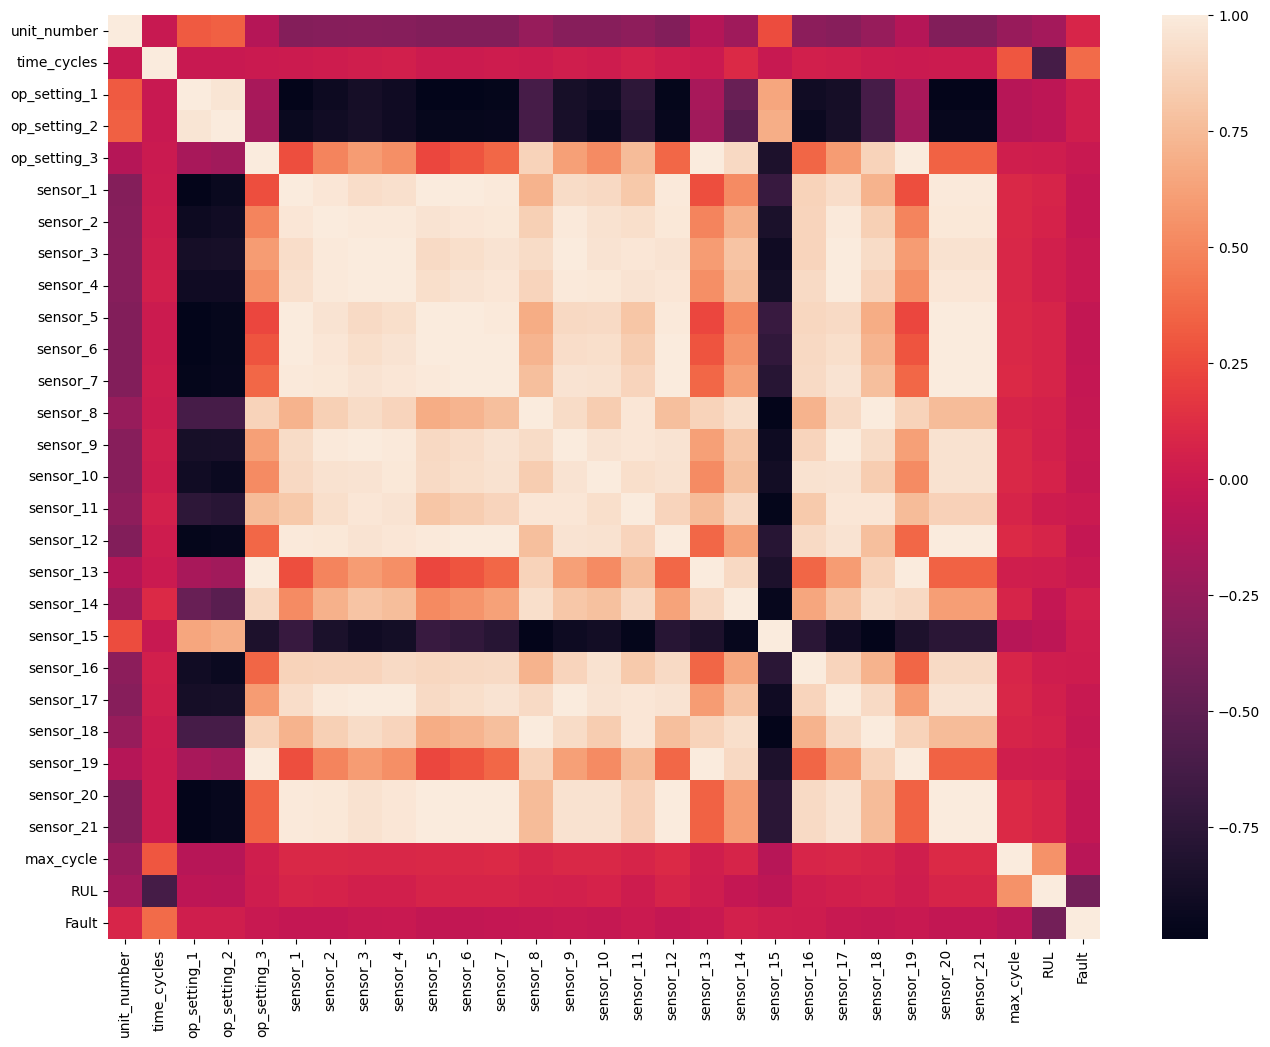

In [16]:
plt.figure(figsize=(16,12))

sns.heatmap(data.corr(numeric_only=True))

plt.show()

5.  Sensors Behavior According to Fault Classes

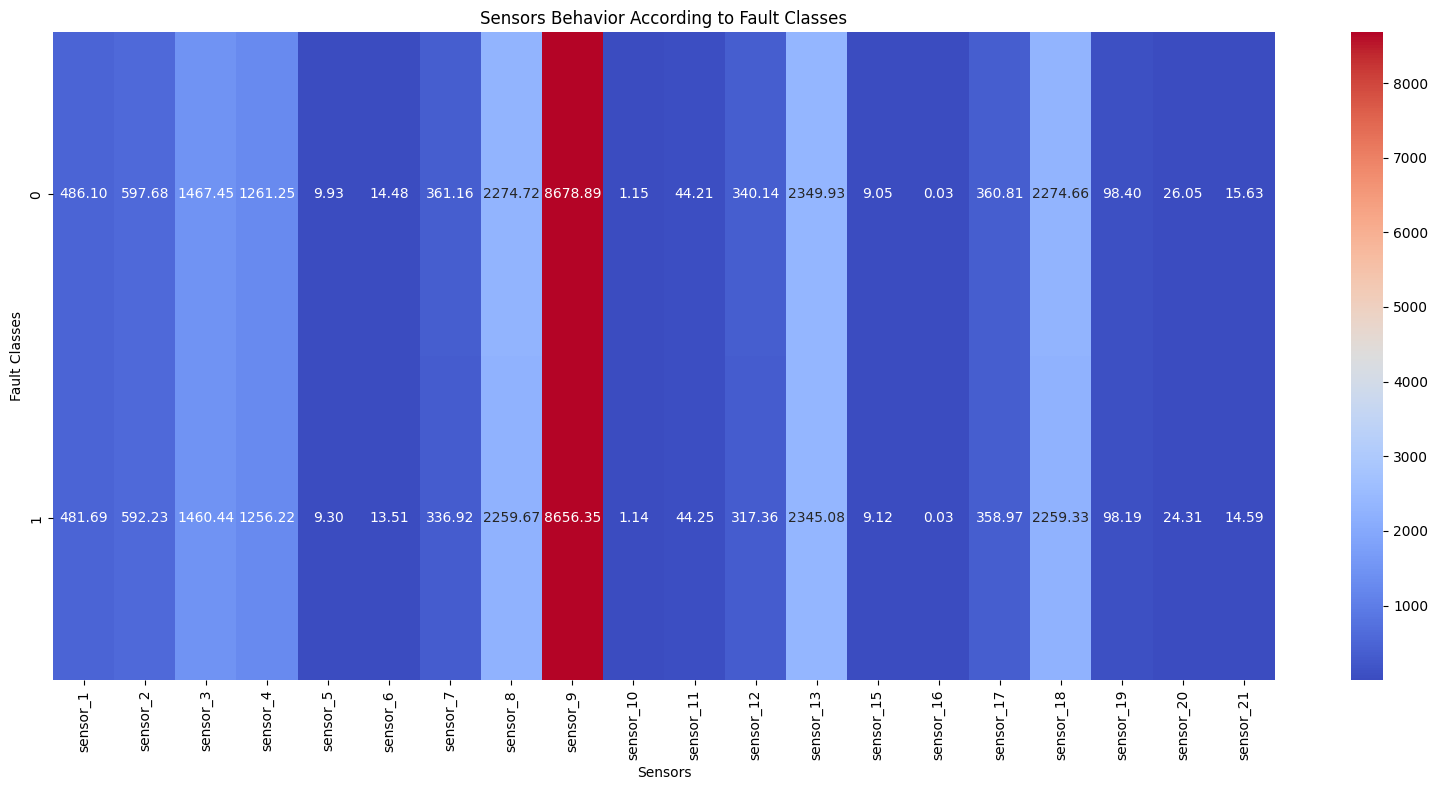

In [17]:


sensors = [
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

fault_sensor_mean = data.groupby("Fault")[sensors].mean()


plt.figure(figsize=(16,8))

sns.heatmap(
    fault_sensor_mean,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Sensors Behavior According to Fault Classes")
plt.xlabel("Sensors")
plt.ylabel("Fault Classes")

plt.tight_layout()
plt.show()

### Preparing Features and Target Variable & Splitting Training and Testing Data

1.  Preparing Features and Target Variable

In [18]:
x = data.drop(
    ["Fault", "RUL", "max_cycle", "engine_id", "dataset"],
    axis=1
)
y = data["Fault"]

2. Splitting Training and Testing Data

In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

### Handling Class Imbalance Using SMOTE

1. Applying the SMOTE 

In [20]:

smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

C:\Users\mouch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


2. Fault Class Distribution after SMOTE

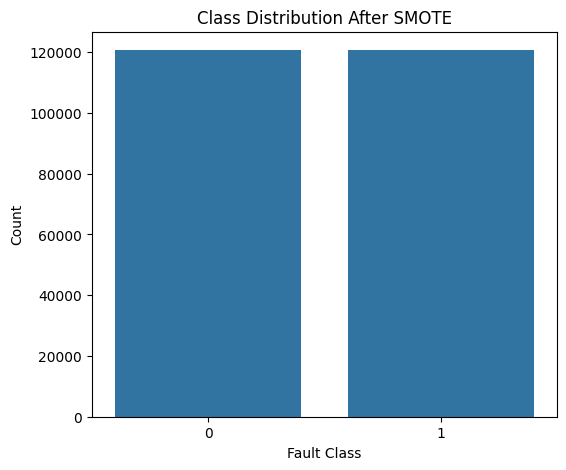

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_resampled)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Fault Class")
plt.ylabel("Count")

plt.show()

# Machine Learning Models for Fault Classification

## Random Forest Classification Model

1. Random Forest Hyperparameter Optimization

In [22]:
params_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    params_rf,
    n_iter=5,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rand_rf.fit(x_resampled, y_resampled)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='f1')

2. Best Random Forest Parameters

In [26]:
rand_rf.best_params_

{'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20}

3.  Training the Random Forest Model

In [27]:
rf = rand_rf.best_estimator_

rf.fit(x_resampled, y_resampled)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

4. Random Forest Predictions

In [28]:
y_pred_rf = rf.predict(x_test)

5. Random Forest Accuracy

In [29]:
rf_acc = accuracy_score(y_test, y_pred_rf)

print(rf_acc)

0.9463706660014967


6.  Random Forest Confusion Matrix

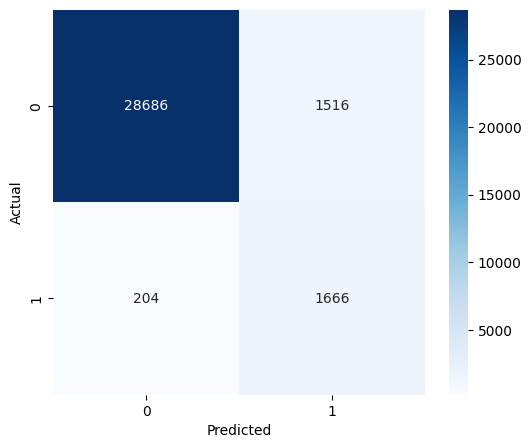

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

7. Random Forest Feature Importance

In [31]:
imp_rf = pd.DataFrame({
    "Feature": x_resampled.columns,
    "Importance": rf.feature_importances_
})

imp_rf = imp_rf.sort_values(
    by="Importance",
    ascending=False
)

imp_rf.head(10)

,Feature,Importance
1,time_cycles,0.290593
17,sensor_13,0.128657
15,sensor_11,0.072827
8,sensor_4,0.060222
19,sensor_15,0.058018
18,sensor_14,0.045962
12,sensor_8,0.040501
0,unit_number,0.032406
16,sensor_12,0.031870
25,sensor_21,0.030719


8. RF Classification Report

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     30202
           1       0.52      0.89      0.66      1870

    accuracy                           0.95     32072
   macro avg       0.76      0.92      0.82     32072
weighted avg       0.97      0.95      0.95     32072



9. Visualization of Important Features in RF

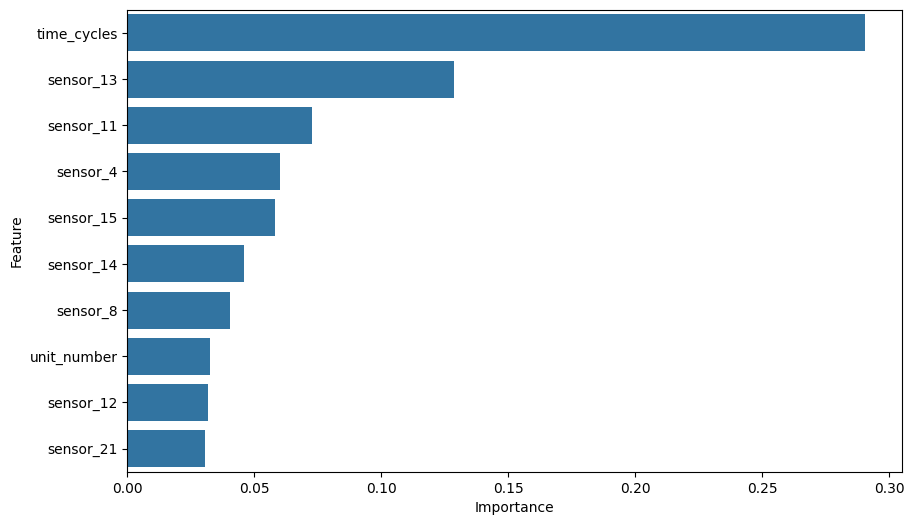

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=imp_rf.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

## XGBoost Classification Model

1. Defining XGBoost Hyperparameters

In [33]:
params_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

2. Searching for Optimal XGBoost Parameters

In [34]:
rand_xgb = RandomizedSearchCV(
        XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    params_xgb,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rand_xgb.fit(x_resampled, y_resampled)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1')

3. Best XGBoost Parameters

In [46]:
rand_xgb.best_params_

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}

4. Training the XGBoost Model

In [35]:
xgb = rand_xgb.best_estimator_

xgb.fit(x_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

5. XGBoost Predictions

In [36]:
y_pred_xgb = xgb.predict(x_test)

6. XGBoost Accuracy

In [37]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(xgb_acc)

0.9721563981042654


7. XGBoost Classification Report

In [38]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     30202
           1       0.70      0.93      0.79      1870

    accuracy                           0.97     32072
   macro avg       0.85      0.95      0.89     32072
weighted avg       0.98      0.97      0.97     32072



8. XGBoost Confusion Matrix

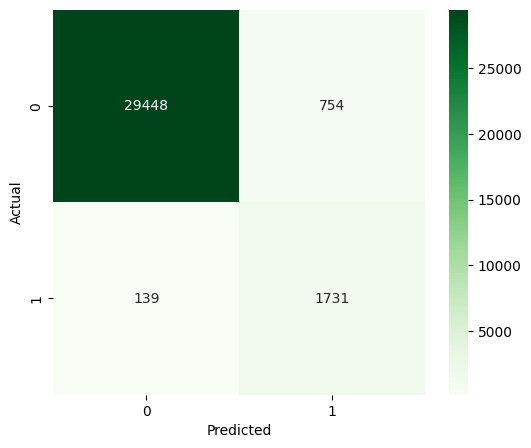

In [39]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

9. XGBoost Feature Importance

In [40]:
imp_xgb = pd.DataFrame({
    "Feature": x_resampled.columns,
    "Importance": xgb.feature_importances_
})

imp_xgb = imp_xgb.sort_values(
    by="Importance",
    ascending=False
)

imp_xgb.head(10)

,Feature,Importance
1,time_cycles,0.248769
20,sensor_16,0.112552
19,sensor_15,0.078710
17,sensor_13,0.064816
6,sensor_2,0.053448
15,sensor_11,0.049313
14,sensor_10,0.047204
0,unit_number,0.041548
10,sensor_6,0.041119
25,sensor_21,0.034648


10. Visualization of Important Features in XGBoost

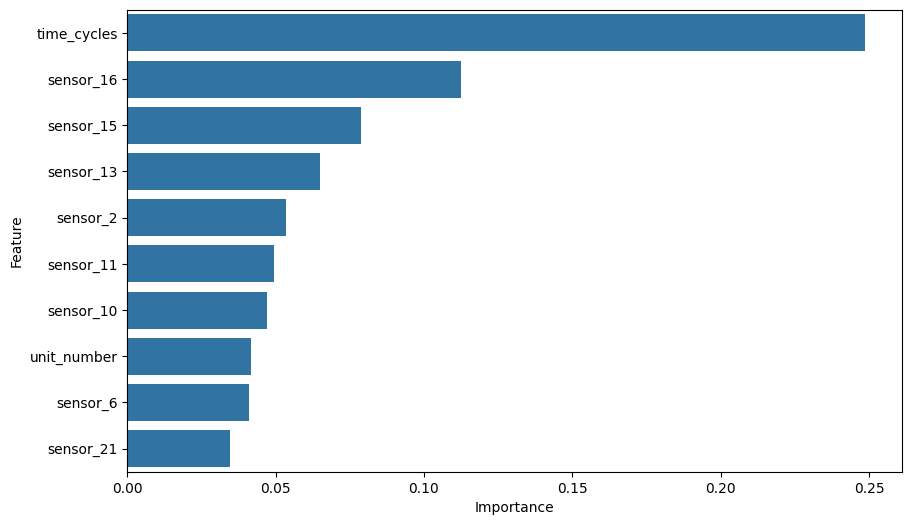

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=imp_xgb.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

# Random Forest and XGBoost Accuracy Comparison

1. Extracting Evaluation Metrics

In [42]:
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

2. Performance Metrics Comparison

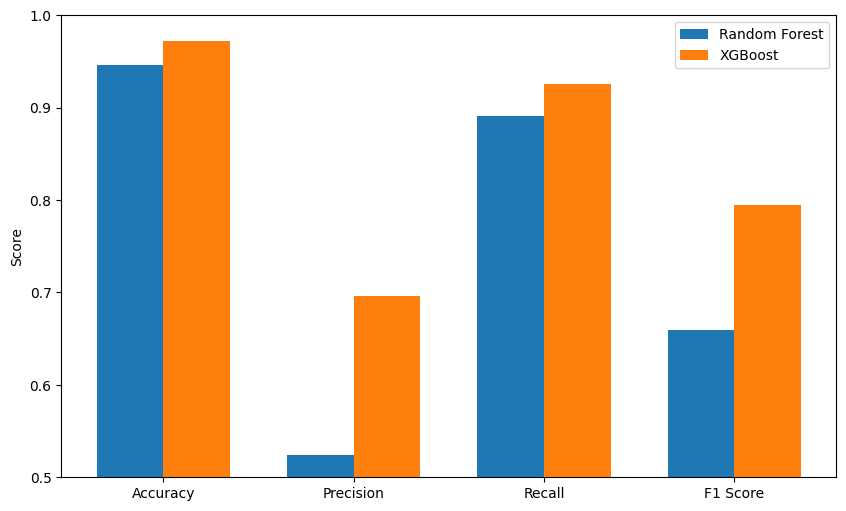

In [44]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

rf_scores = [
    rf_acc,
    rf_precision,
    rf_recall,
    rf_f1
]

xgb_scores = [
    xgb_acc,
    xgb_precision,
    xgb_recall,
    xgb_f1
]

x = np.arange(len(metrics))

w = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - w/2, rf_scores, width=w, label="Random Forest")

plt.bar(x + w/2, xgb_scores, width=w, label="XGBoost")

plt.xticks(x, metrics)

plt.ylim(0.5, 1.0)

plt.ylabel("Score")

plt.legend()

plt.show()